<a href="https://colab.research.google.com/github/evakonstantinova/EfficientNet-B0/blob/main/HQNN_without_tanh_%C3%97_%CF%80.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install pennylane kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.8 MB/s eta 0:00:00


In [ ]:
import os
import random
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms

from PIL import Image

import pennylane as qml
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("PyTorch:", torch.__version__)
print("PennyLane:", qml.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
PennyLane: 0.45.1
CUDA available: True
GPU: Tesla T4


In [ ]:
SEED = 42

def set_global_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_global_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random seed fixed:", SEED)

Random seed fixed: 42


In [ ]:
path = kagglehub.dataset_download(
    "masoudnickparvar/brain-tumor-mri-dataset"
)

classes = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

all_files = []
all_labels = []


for class_name in classes:

    for folder in ["Training", "Testing"]:

        class_path = (
            Path(path)
            / folder
            / class_name
        )

        for file_path in class_path.iterdir():

            if file_path.is_file():

                all_files.append(
                    str(file_path)
                )

                all_labels.append(
                    class_name
                )


train_files, temp_files, train_labels, temp_labels = (
    train_test_split(
        all_files,
        all_labels,
        test_size=0.30,
        random_state=42,
        stratify=all_labels
    )
)


val_files, test_files, val_labels, test_labels = (
    train_test_split(
        temp_files,
        temp_labels,
        test_size=0.50,
        random_state=42,
        stratify=temp_labels
    )
)


print("Total images:", len(all_files))

print(
    "Training:",
    len(train_files),
    Counter(train_labels)
)

print(
    "Validation:",
    len(val_files),
    Counter(val_labels)
)

print(
    "Testing:",
    len(test_files),
    Counter(test_labels)
)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Total images: 7200
Training: 5040 Counter({'notumor': 1260, 'pituitary': 1260, 'glioma': 1260, 'meningioma': 1260})
Validation: 1080 Counter({'notumor': 270, 'glioma': 270, 'meningioma': 270, 'pituitary': 270})
Testing: 1080 Counter({'meningioma': 270, 'notumor': 270, 'glioma': 270, 'pituitary': 270})


In [ ]:
# UPLOAD SAVED ORIGINAL HQNN CHECKPOINT

from google.colab import files
import os
import torch

uploaded = files.upload()

if len(uploaded) != 1:
    raise ValueError("Please upload exactly one .pth checkpoint.")

uploaded_filename = next(iter(uploaded))

HQNN_CHECKPOINT = f"/content/{uploaded_filename}"

print("Checkpoint uploaded:")
print(HQNN_CHECKPOINT)

Saving BEST_HQNN (1).pth to BEST_HQNN (1).pth
Checkpoint uploaded:
/content/BEST_HQNN (1).pth


In [ ]:
# LOAD SAVED HQNN CHECKPOINT INTO MEMORY

saved_hqnn_state = torch.load(
    HQNN_CHECKPOINT,
    map_location="cpu",
    weights_only=True
)

print("HQNN checkpoint loaded successfully.")

print("\nCheckpoint contains:")
for key in saved_hqnn_state.keys():
    print(key)

HQNN checkpoint loaded successfully.

Checkpoint contains:
features.0.0.weight
features.0.1.weight
features.0.1.bias
features.0.1.running_mean
features.0.1.running_var
features.0.1.num_batches_tracked
features.1.0.block.0.0.weight
features.1.0.block.0.1.weight
features.1.0.block.0.1.bias
features.1.0.block.0.1.running_mean
features.1.0.block.0.1.running_var
features.1.0.block.0.1.num_batches_tracked
features.1.0.block.1.fc1.weight
features.1.0.block.1.fc1.bias
features.1.0.block.1.fc2.weight
features.1.0.block.1.fc2.bias
features.1.0.block.2.0.weight
features.1.0.block.2.1.weight
features.1.0.block.2.1.bias
features.1.0.block.2.1.running_mean
features.1.0.block.2.1.running_var
features.1.0.block.2.1.num_batches_tracked
features.2.0.block.0.0.weight
features.2.0.block.0.1.weight
features.2.0.block.0.1.bias
features.2.0.block.0.1.running_mean
features.2.0.block.0.1.running_var
features.2.0.block.0.1.num_batches_tracked
features.2.0.block.1.0.weight
features.2.0.block.1.1.weight
features.

In [ ]:
# RESTORE THE SAME EFFICIENTNET-B0 BACKBONE
# FROM THE SAVED ORIGINAL HQNN

efficientnet = models.efficientnet_b0(
    weights=None
)

FEATURE_DIM = efficientnet.classifier[1].in_features

assert FEATURE_DIM == 1280


# Take ONLY the EfficientNet feature extractor weights
# from the old saved HQNN.
# We do NOT load the old feature_reduction,
# quantum_layer, or classifier.

feature_state = {
    key.replace("features.", "", 1): value
    for key, value in saved_hqnn_state.items()
    if key.startswith("features.")
}


efficientnet.features.load_state_dict(
    feature_state,
    strict=True
)


# Freeze the restored EfficientNet backbone
for param in efficientnet.features.parameters():
    param.requires_grad = False


print("EfficientNet-B0 backbone restored successfully.")
print("Feature dimension:", FEATURE_DIM)

print(
    "Trainable EfficientNet parameters:",
    sum(
        p.numel()
        for p in efficientnet.features.parameters()
        if p.requires_grad
    )
)

EfficientNet-B0 backbone restored successfully.
Feature dimension: 1280
Trainable EfficientNet parameters: 0


In [ ]:
# SAME IMAGE PREPROCESSING AS THE ORIGINAL HQNN

class_to_idx = {
    "glioma": 0,
    "meningioma": 1,
    "notumor": 2,
    "pituitary": 3
}


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class BrainTumorDataset(Dataset):

    def __init__(self, files, labels, transform=None):
        self.files = files
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):

        image = Image.open(
            self.files[idx]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[
            self.labels[idx]
        ]

        return image, label


train_dataset = BrainTumorDataset(
    train_files,
    train_labels,
    transform=train_transform
)

val_dataset = BrainTumorDataset(
    val_files,
    val_labels,
    transform=val_test_transform
)

test_dataset = BrainTumorDataset(
    test_files,
    test_labels,
    transform=val_test_transform
)


BATCH_SIZE = 32


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))
print("Batch size:", BATCH_SIZE)

Training images: 5040
Validation images: 1080
Testing images: 1080
Batch size: 32


In [ ]:
# NEW QUANTUM CIRCUIT
# IDENTICAL TO THE ORIGINAL HQNN
# EXCEPT THERE WILL BE NO tanh(x) * pi

N_QUBITS = 4
N_Q_LAYERS = 2


quantum_device = qml.device(
    "default.qubit",
    wires=N_QUBITS
)


@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def quantum_circuit_no_scaling(inputs, weights):

    # Directly encode the 4 reduced features
    qml.AngleEmbedding(
        inputs,
        wires=range(N_QUBITS),
        rotation="Y"
    )

    # Same quantum processing as original HQNN
    qml.StronglyEntanglingLayers(
        weights,
        wires=range(N_QUBITS)
    )

    # Same Pauli-Z measurements
    return [
        qml.expval(qml.PauliZ(i))
        for i in range(N_QUBITS)
    ]


weight_shapes = {
    "weights": (
        N_Q_LAYERS,
        N_QUBITS,
        3
    )
}


set_global_seed(SEED)

quantum_layer_no_scaling = qml.qnn.TorchLayer(
    quantum_circuit_no_scaling,
    weight_shapes
)


print("Quantum layer created successfully.")
print("Qubits:", N_QUBITS)
print("Quantum layers:", N_Q_LAYERS)
print("tanh × pi scaling: REMOVED")

Quantum layer created successfully.
Qubits: 4
Quantum layers: 2
tanh × pi scaling: REMOVED


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [ ]:
# NEW QUANTUM CIRCUIT WITHOUT tanh(x) * pi

N_QUBITS = 4
N_Q_LAYERS = 2

quantum_device = qml.device(
    "default.qubit",
    wires=N_QUBITS
)


@qml.qnode(
    quantum_device,
    interface="torch",
    diff_method="backprop"
)
def quantum_circuit_no_scaling(inputs, weights):

    # DIRECTLY USE THE 4 REDUCED FEATURES
    # AS RY ROTATION ANGLES

    qml.AngleEmbedding(
        inputs,
        wires=range(N_QUBITS),
        rotation="Y"
    )

    qml.StronglyEntanglingLayers(
        weights,
        wires=range(N_QUBITS)
    )

    return [
        qml.expval(qml.PauliZ(i))
        for i in range(N_QUBITS)
    ]


weight_shapes = {
    "weights": (
        N_Q_LAYERS,
        N_QUBITS,
        3
    )
}


set_global_seed(SEED)

quantum_layer_no_scaling = qml.qnn.TorchLayer(
    quantum_circuit_no_scaling,
    weight_shapes
)


print("Quantum layer created successfully.")
print("Qubits:", N_QUBITS)
print("Quantum layers:", N_Q_LAYERS)
print("tanh × pi scaling: REMOVED")

Quantum layer created successfully.
Qubits: 4
Quantum layers: 2
tanh × pi scaling: REMOVED


In [ ]:
class HQNNNoScaling(nn.Module):

    def __init__(
        self,
        trained_efficientnet,
        quantum_layer
    ):
        super().__init__()

        # SAME SAVED EFFICIENTNET BACKBONE
        self.features = trained_efficientnet.features
        self.avgpool = trained_efficientnet.avgpool

        # FREEZE BACKBONE
        for param in self.features.parameters():
            param.requires_grad = False

        # NEW 1280 -> 4 REDUCTION
        self.feature_reduction = nn.Linear(
            FEATURE_DIM,
            N_QUBITS
        )

        # NEW QUANTUM LAYER
        self.quantum_layer = quantum_layer

        # NEW 4 -> 4 CLASSIFIER
        self.classifier = nn.Linear(
            N_QUBITS,
            4
        )


    def forward(self, x):

        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        # 1280 -> 4
        x = self.feature_reduction(x)

        # IMPORTANT:
        # NO torch.tanh(x) * torch.pi

        x = x.cpu()

        x = self.quantum_layer(x)

        classifier_device = next(
            self.classifier.parameters()
        ).device

        x = x.to(classifier_device)

        x = self.classifier(x)

        return x

In [ ]:
set_global_seed(SEED)

hqnn_no_scaling = HQNNNoScaling(
    efficientnet,
    quantum_layer_no_scaling
)

print(hqnn_no_scaling)

HQNNNoScaling(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiva

In [ ]:
backbone_trainable = sum(
    p.numel()
    for p in hqnn_no_scaling.features.parameters()
    if p.requires_grad
)

total_trainable = sum(
    p.numel()
    for p in hqnn_no_scaling.parameters()
    if p.requires_grad
)

print(
    "Trainable EfficientNet parameters:",
    backbone_trainable
)

print(
    "Total trainable parameters:",
    total_trainable
)

for name, parameter in hqnn_no_scaling.named_parameters():

    if parameter.requires_grad:

        print(
            name,
            tuple(parameter.shape),
            parameter.numel()
        )

Trainable EfficientNet parameters: 0
Total trainable parameters: 5168
feature_reduction.weight (4, 1280) 5120
feature_reduction.bias (4,) 4
quantum_layer.weights (2, 4, 3) 24
classifier.weight (4, 4) 16
classifier.bias (4,) 4


In [ ]:
# MOVE FROZEN EFFICIENTNET BACKBONE TO GPU

feature_device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Feature extraction device:", feature_device)

hqnn_no_scaling.features = hqnn_no_scaling.features.to(feature_device)
hqnn_no_scaling.avgpool = hqnn_no_scaling.avgpool.to(feature_device)

hqnn_no_scaling.features.eval()
hqnn_no_scaling.avgpool.eval()


def extract_efficientnet_features(data_loader):

    all_features = []
    all_labels = []

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(feature_device)

            features = hqnn_no_scaling.features(images)
            features = hqnn_no_scaling.avgpool(features)
            features = torch.flatten(features, 1)

            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

    return (
        torch.cat(all_features, dim=0),
        torch.cat(all_labels, dim=0)
    )


print("Feature extraction function ready.")

Feature extraction device: cuda
Feature extraction function ready.


In [ ]:
print("Extracting validation features...")

val_features, val_labels = extract_efficientnet_features(
    val_loader
)

print("Validation feature extraction completed.")
print("Validation features shape:", val_features.shape)
print("Validation labels shape:", val_labels.shape)

Extracting validation features...
Validation feature extraction completed.
Validation features shape: torch.Size([1080, 1280])
Validation labels shape: torch.Size([1080])


In [ ]:
# TRAINING SETUP FOR HQNN WITHOUT tanh × pi

# Quantum part remains on CPU
hqnn_no_scaling.feature_reduction = (
    hqnn_no_scaling.feature_reduction.cpu()
)

hqnn_no_scaling.quantum_layer = (
    hqnn_no_scaling.quantum_layer.cpu()
)

hqnn_no_scaling.classifier = (
    hqnn_no_scaling.classifier.cpu()
)


criterion = nn.CrossEntropyLoss()


trainable_parameters = (
    list(hqnn_no_scaling.feature_reduction.parameters())
    + list(hqnn_no_scaling.quantum_layer.parameters())
    + list(hqnn_no_scaling.classifier.parameters())
)


optimizer = torch.optim.Adam(
    trainable_parameters,
    lr=0.001
)


NUM_EPOCHS = 10

best_val_loss = float("inf")
best_epoch = 0


print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Maximum epochs:", NUM_EPOCHS)
print("EfficientNet backbone trainable: NO")
print("tanh × pi scaling: REMOVED")

Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Maximum epochs: 10
EfficientNet backbone trainable: NO
tanh × pi scaling: REMOVED


In [ ]:
train_losses = []
train_accuracies = []
train_f1_scores = []

val_losses = []
val_accuracies = []
val_f1_scores = []

training_start_time = time.time()


for epoch in range(NUM_EPOCHS):

    set_global_seed(SEED + epoch)

    print(f"\nEPOCH {epoch + 1}/{NUM_EPOCHS}")
    print("Extracting augmented training features...")

    # Re-extract training features every epoch
    # so the image augmentation remains active
    train_features, train_labels = extract_efficientnet_features(
        train_loader
    )

    train_feature_dataset = TensorDataset(
        train_features,
        train_labels
    )

    train_feature_loader = DataLoader(
        train_feature_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0
    )

    # -------------------------
    # TRAIN
    # -------------------------

    hqnn_no_scaling.feature_reduction.train()
    hqnn_no_scaling.quantum_layer.train()
    hqnn_no_scaling.classifier.train()

    running_train_loss = 0.0
    train_predictions = []
    train_targets = []

    for features, labels in train_feature_loader:

        optimizer.zero_grad()

        # 1280 -> 4
        outputs = hqnn_no_scaling.feature_reduction(
            features
        )

        # IMPORTANT:
        # NO tanh
        # NO multiplication by pi

        # Quantum processing
        outputs = hqnn_no_scaling.quantum_layer(
            outputs
        )

        # Final classifier
        outputs = hqnn_no_scaling.classifier(
            outputs
        )

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_train_loss += (
            loss.item() * features.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        train_predictions.extend(
            predictions.detach().cpu().numpy()
        )

        train_targets.extend(
            labels.cpu().numpy()
        )

    epoch_train_loss = (
        running_train_loss
        / len(train_feature_dataset)
    )

    epoch_train_accuracy = accuracy_score(
        train_targets,
        train_predictions
    )

    epoch_train_f1 = f1_score(
        train_targets,
        train_predictions,
        average="macro"
    )

    # -------------------------
    # VALIDATION
    # -------------------------

    hqnn_no_scaling.feature_reduction.eval()
    hqnn_no_scaling.quantum_layer.eval()
    hqnn_no_scaling.classifier.eval()

    val_feature_dataset = TensorDataset(
        val_features,
        val_labels
    )

    val_feature_loader = DataLoader(
        val_feature_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0
    )

    running_val_loss = 0.0
    val_predictions = []
    val_targets = []

    with torch.no_grad():

        for features, labels in val_feature_loader:

            outputs = hqnn_no_scaling.feature_reduction(
                features
            )

            # NO tanh × pi

            outputs = hqnn_no_scaling.quantum_layer(
                outputs
            )

            outputs = hqnn_no_scaling.classifier(
                outputs
            )

            loss = criterion(
                outputs,
                labels
            )

            running_val_loss += (
                loss.item() * features.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_predictions.extend(
                predictions.cpu().numpy()
            )

            val_targets.extend(
                labels.cpu().numpy()
            )

    epoch_val_loss = (
        running_val_loss
        / len(val_feature_dataset)
    )

    epoch_val_accuracy = accuracy_score(
        val_targets,
        val_predictions
    )

    epoch_val_f1 = f1_score(
        val_targets,
        val_predictions,
        average="macro"
    )

    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_accuracy)
    train_f1_scores.append(epoch_train_f1)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)
    val_f1_scores.append(epoch_val_f1)

    # -------------------------
    # SAVE BEST CHECKPOINT
    # -------------------------

    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_epoch = epoch + 1

        torch.save(
            hqnn_no_scaling.state_dict(),
            "/content/BEST_HQNN_NO_TANH_PI.pth"
        )

        marker = " <-- BEST CHECKPOINT"

    else:
        marker = ""

    print(
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy:.4f} | "
        f"Train F1: {epoch_train_f1:.4f}"
    )

    print(
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy:.4f} | "
        f"Val F1: {epoch_val_f1:.4f}"
        f"{marker}"
    )


training_time = time.time() - training_start_time


print("\nTRAINING COMPLETED")
print("Best epoch:", best_epoch)
print("Best validation loss:", round(best_val_loss, 4))
print(
    "Training time:",
    round(training_time / 60, 2),
    "minutes"
)


EPOCH 1/10
Extracting augmented training features...
Train Loss: 1.2387 | Train Acc: 0.4843 | Train F1: 0.4090
Val Loss: 1.0938 | Val Acc: 0.7278 | Val F1: 0.6909 <-- BEST CHECKPOINT

EPOCH 2/10
Extracting augmented training features...
Train Loss: 0.8821 | Train Acc: 0.8938 | Train F1: 0.8917
Val Loss: 0.7219 | Val Acc: 0.9139 | Val F1: 0.9132 <-- BEST CHECKPOINT

EPOCH 3/10
Extracting augmented training features...
Train Loss: 0.5426 | Train Acc: 0.9437 | Train F1: 0.9432
Val Loss: 0.4721 | Val Acc: 0.9287 | Val F1: 0.9281 <-- BEST CHECKPOINT

EPOCH 4/10
Extracting augmented training features...
Train Loss: 0.3516 | Train Acc: 0.9575 | Train F1: 0.9573
Val Loss: 0.3482 | Val Acc: 0.9389 | Val F1: 0.9382 <-- BEST CHECKPOINT

EPOCH 5/10
Extracting augmented training features...
Train Loss: 0.2554 | Train Acc: 0.9657 | Train F1: 0.9656
Val Loss: 0.2820 | Val Acc: 0.9435 | Val F1: 0.9429 <-- BEST CHECKPOINT

EPOCH 6/10
Extracting augmented training features...
Train Loss: 0.2089 | Train

In [ ]:
# LOAD BEST HQNN WITHOUT tanh × pi

best_state = torch.load(
    "/content/BEST_HQNN_NO_TANH_PI.pth",
    map_location="cpu",
    weights_only=True
)

hqnn_no_scaling.load_state_dict(
    best_state
)

print("Best HQNN without tanh × pi loaded successfully.")
print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)


# -----------------------------------
# EXTRACT TEST EFFICIENTNET FEATURES
# -----------------------------------

print("\nExtracting test features...")

test_features, test_labels = extract_efficientnet_features(
    test_loader
)

print("Test feature extraction completed.")
print("Test features shape:", test_features.shape)
print("Test labels shape:", test_labels.shape)


# -----------------------------------
# CREATE TEST FEATURE LOADER
# -----------------------------------

test_feature_dataset = TensorDataset(
    test_features,
    test_labels
)

test_feature_loader = DataLoader(
    test_feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)


# -----------------------------------
# EVALUATION MODE
# -----------------------------------

hqnn_no_scaling.feature_reduction.eval()
hqnn_no_scaling.quantum_layer.eval()
hqnn_no_scaling.classifier.eval()


test_targets = []
test_predictions = []
test_probabilities = []

running_test_loss = 0.0


# -----------------------------------
# FINAL TEST
# -----------------------------------

with torch.no_grad():

    for features, labels in test_feature_loader:

        # 1280 -> 4
        outputs = hqnn_no_scaling.feature_reduction(
            features
        )

        # IMPORTANT:
        # NO tanh
        # NO multiplication by pi

        # Quantum processing
        outputs = hqnn_no_scaling.quantum_layer(
            outputs
        )

        # Final 4-class classifier
        outputs = hqnn_no_scaling.classifier(
            outputs
        )

        loss = criterion(
            outputs,
            labels
        )

        running_test_loss += (
            loss.item() * features.size(0)
        )

        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        test_targets.extend(
            labels.cpu().numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_probabilities.extend(
            probabilities.cpu().numpy()
        )


# -----------------------------------
# CONVERT TO NUMPY
# -----------------------------------

test_targets = np.array(
    test_targets
)

test_predictions = np.array(
    test_predictions
)

test_probabilities = np.array(
    test_probabilities
)


# -----------------------------------
# METRICS
# -----------------------------------

test_loss = (
    running_test_loss
    / len(test_feature_dataset)
)

test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_precision = precision_score(
    test_targets,
    test_predictions,
    average="macro"
)

test_recall = recall_score(
    test_targets,
    test_predictions,
    average="macro"
)

test_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro"
)

test_roc_auc = roc_auc_score(
    test_targets,
    test_probabilities,
    multi_class="ovr",
    average="macro"
)


# -----------------------------------
# PRINT FINAL RESULTS
# -----------------------------------

print("\nFINAL HQNN WITHOUT tanh × pi TEST RESULTS")

print(
    f"Test Loss:       {test_loss:.4f}"
)

print(
    f"Accuracy:        "
    f"{test_accuracy:.4f} "
    f"({test_accuracy * 100:.2f}%)"
)

print(
    f"Macro Precision: "
    f"{test_precision:.4f} "
    f"({test_precision * 100:.2f}%)"
)

print(
    f"Macro Recall:    "
    f"{test_recall:.4f} "
    f"({test_recall * 100:.2f}%)"
)

print(
    f"Macro F1:        "
    f"{test_f1:.4f} "
    f"({test_f1 * 100:.2f}%)"
)

print(
    f"Macro ROC-AUC:   "
    f"{test_roc_auc:.4f} "
    f"({test_roc_auc * 100:.2f}%)"
)


# -----------------------------------
# CLASSIFICATION REPORT
# -----------------------------------

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=[
            "Glioma",
            "Meningioma",
            "No Tumor",
            "Pituitary"
        ],
        digits=4
    )
)


# -----------------------------------
# CONFUSION MATRIX
# -----------------------------------

print("\nCONFUSION MATRIX")

print(
    confusion_matrix(
        test_targets,
        test_predictions
    )
)

Best HQNN without tanh × pi loaded successfully.
Best epoch: 10
Best validation loss: 0.17608390351136524

Extracting test features...
Test feature extraction completed.
Test features shape: torch.Size([1080, 1280])
Test labels shape: torch.Size([1080])

FINAL HQNN WITHOUT tanh × pi TEST RESULTS
Test Loss:       0.2316
Accuracy:        0.9407 (94.07%)
Macro Precision: 0.9401 (94.01%)
Macro Recall:    0.9407 (94.07%)
Macro F1:        0.9402 (94.02%)
Macro ROC-AUC:   0.9905 (99.05%)

CLASSIFICATION REPORT

              precision    recall  f1-score   support

      Glioma     0.9176    0.9074    0.9125       270
  Meningioma     0.9183    0.8741    0.8956       270
    No Tumor     0.9675    0.9926    0.9799       270
   Pituitary     0.9570    0.9889    0.9727       270

    accuracy                         0.9407      1080
   macro avg     0.9401    0.9407    0.9402      1080
weighted avg     0.9401    0.9407    0.9402      1080


CONFUSION MATRIX
[[245  18   3   4]
 [ 20 236   6   8]

In [ ]:
# DIAGNOSTIC ANALYSIS OF ORIGINAL tanh(x) * pi

In [ ]:
# Reconstruct the ORIGINAL trained 1280 -> 4 layer
# from the HQNN WITH tanh(x) * pi

original_feature_reduction = nn.Linear(
    FEATURE_DIM,
    N_QUBITS
)

original_feature_reduction.load_state_dict({
    "weight": saved_hqnn_state["feature_reduction.weight"],
    "bias": saved_hqnn_state["feature_reduction.bias"]
})

original_feature_reduction.eval()


with torch.no_grad():

    # Values produced by the ORIGINAL HQNN
    # immediately BEFORE tanh(x)
    x_pre_tanh = original_feature_reduction(
        val_features.cpu()
    )

    # What the original HQNN actually did
    tanh_values = torch.tanh(x_pre_tanh)

    angles = torch.pi * tanh_values

    # tanh derivative
    tanh_derivative = (
        1.0 - tanh_values.pow(2)
    )


print("Original HQNN tanh diagnostic ready.")
print("Shape:", x_pre_tanh.shape)

Original HQNN tanh diagnostic ready.
Shape: torch.Size([1080, 4])


In [ ]:
def percentage(condition):
    return condition.float().mean().item() * 100


x_abs = x_pre_tanh.abs()


print("\n=== PRE-TANH VALUES ===")

print(
    "Mean:",
    x_pre_tanh.mean().item()
)

print(
    "Std:",
    x_pre_tanh.std().item()
)

print(
    "Minimum:",
    x_pre_tanh.min().item()
)

print(
    "Maximum:",
    x_pre_tanh.max().item()
)


print("\n=== SATURATION CHECK ===")

print(
    "|x| > 1:",
    f"{percentage(x_abs > 1):.2f}%"
)

print(
    "|x| > 2:",
    f"{percentage(x_abs > 2):.2f}%"
)

print(
    "|x| > 3:",
    f"{percentage(x_abs > 3):.2f}%"
)

print(
    "|x| > 4:",
    f"{percentage(x_abs > 4):.2f}%"
)


print("\n=== TANH OUTPUT ===")

print(
    "|tanh(x)| > 0.90:",
    f"{percentage(tanh_values.abs() > 0.90):.2f}%"
)

print(
    "|tanh(x)| > 0.95:",
    f"{percentage(tanh_values.abs() > 0.95):.2f}%"
)

print(
    "|tanh(x)| > 0.99:",
    f"{percentage(tanh_values.abs() > 0.99):.2f}%"
)


print("\n=== ANGLES NEAR +/- PI ===")

print(
    "|angle| > 0.90*pi:",
    f"{percentage(angles.abs() > 0.90 * torch.pi):.2f}%"
)

print(
    "|angle| > 0.95*pi:",
    f"{percentage(angles.abs() > 0.95 * torch.pi):.2f}%"
)

print(
    "|angle| > 0.99*pi:",
    f"{percentage(angles.abs() > 0.99 * torch.pi):.2f}%"
)


print("\n=== TANH GRADIENT CHECK ===")

print(
    "Mean tanh derivative:",
    tanh_derivative.mean().item()
)

print(
    "Median tanh derivative:",
    tanh_derivative.median().item()
)

print(
    "Derivative < 0.10:",
    f"{percentage(tanh_derivative < 0.10):.2f}%"
)

print(
    "Derivative < 0.05:",
    f"{percentage(tanh_derivative < 0.05):.2f}%"
)

print(
    "Derivative < 0.01:",
    f"{percentage(tanh_derivative < 0.01):.2f}%"
)

print(
    "Derivative < 0.001:",
    f"{percentage(tanh_derivative < 0.001):.2f}%"
)


=== PRE-TANH VALUES ===
Mean: -0.2577010989189148
Std: 0.5804471373558044
Minimum: -3.188239336013794
Maximum: 0.959446370601654

=== SATURATION CHECK ===
|x| > 1: 14.72%
|x| > 2: 1.11%
|x| > 3: 0.02%
|x| > 4: 0.00%

=== TANH OUTPUT ===
|tanh(x)| > 0.90: 5.07%
|tanh(x)| > 0.95: 1.81%
|tanh(x)| > 0.99: 0.09%

=== ANGLES NEAR +/- PI ===
|angle| > 0.90*pi: 5.07%
|angle| > 0.95*pi: 1.81%
|angle| > 0.99*pi: 0.09%

=== TANH GRADIENT CHECK ===
Mean tanh derivative: 0.82178795337677
Median tanh derivative: 0.9807252883911133
Derivative < 0.10: 1.94%
Derivative < 0.05: 0.49%
Derivative < 0.01: 0.02%
Derivative < 0.001: 0.00%


In [ ]:
rows = []

for i in range(N_QUBITS):

    x_i = x_pre_tanh[:, i]
    tanh_i = tanh_values[:, i]
    angle_i = angles[:, i]
    derivative_i = tanh_derivative[:, i]

    rows.append({

        "Feature": i + 1,

        "Mean before tanh":
            x_i.mean().item(),

        "Std before tanh":
            x_i.std().item(),

        "Min":
            x_i.min().item(),

        "Max":
            x_i.max().item(),

        "|x| > 1 (%)":
            percentage(
                x_i.abs() > 1
            ),

        "|x| > 2 (%)":
            percentage(
                x_i.abs() > 2
            ),

        "|angle| > 0.95π (%)":
            percentage(
                angle_i.abs()
                > 0.95 * torch.pi
            ),

        "Mean tanh derivative":
            derivative_i.mean().item(),

        "Derivative < 0.10 (%)":
            percentage(
                derivative_i < 0.10
            )
    })


diagnostic_table = pd.DataFrame(rows)

display(diagnostic_table)

,Feature,Mean before tanh,Std before tanh,Min,Max,|x| > 1 (%),|x| > 2 (%),|angle| > 0.95π (%),Mean tanh derivative,Derivative < 0.10 (%)
0,1,0.016496,0.038482,-0.172376,0.121589,0.000000,0.000000,0.000000,0.998254,0.000000
1,2,-0.351989,0.693990,-2.183423,0.959446,22.870371,0.555556,0.740741,0.674844,0.740741
2,3,-0.100715,0.077195,-0.417830,0.154395,0.000000,0.000000,0.000000,0.984287,0.000000
3,4,-0.594596,0.798203,-3.188239,0.880827,36.018518,3.888889,6.481481,0.629766,7.037037


In [ ]:
print("=== EFFECT OF tanh × pi ON THE FOUR FEATURES ===\n")

for i in range(N_QUBITS):

    raw = x_pre_tanh[:, i]
    transformed = angles[:, i]

    correlation = np.corrcoef(
        raw.numpy(),
        transformed.numpy()
    )[0, 1]

    mean_absolute_change = (
        transformed - raw
    ).abs().mean().item()

    scale_ratio = (
        transformed.std().item()
        / raw.std().item()
    )

    print(f"Feature {i + 1}")

    print(
        f"  Raw std:              "
        f"{raw.std().item():.4f}"
    )

    print(
        f"  After tanh*pi std:    "
        f"{transformed.std().item():.4f}"
    )

    print(
        f"  Std ratio:            "
        f"{scale_ratio:.2f}x"
    )

    print(
        f"  Mean absolute change: "
        f"{mean_absolute_change:.4f}"
    )

    print(
        f"  Correlation:          "
        f"{correlation:.4f}"
    )

    print()

=== EFFECT OF tanh × pi ON THE FOUR FEATURES ===

Feature 1
  Raw std:              0.0385
  After tanh*pi std:    0.1207
  Std ratio:            3.14x
  Mean absolute change: 0.0717
  Correlation:          1.0000

Feature 2
  Raw std:              0.6940
  After tanh*pi std:    1.6398
  Std ratio:            2.36x
  Mean absolute change: 0.9360
  Correlation:          0.9845

Feature 3
  Raw std:              0.0772
  After tanh*pi std:    0.2385
  Std ratio:            3.09x
  Mean absolute change: 0.2277
  Correlation:          0.9999

Feature 4
  Raw std:              0.7982
  After tanh*pi std:    1.5555
  Std ratio:            1.95x
  Mean absolute change: 0.8333
  Correlation:          0.9632



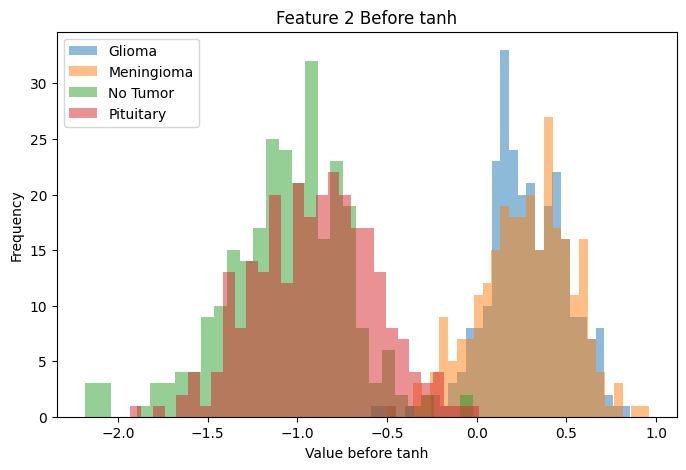

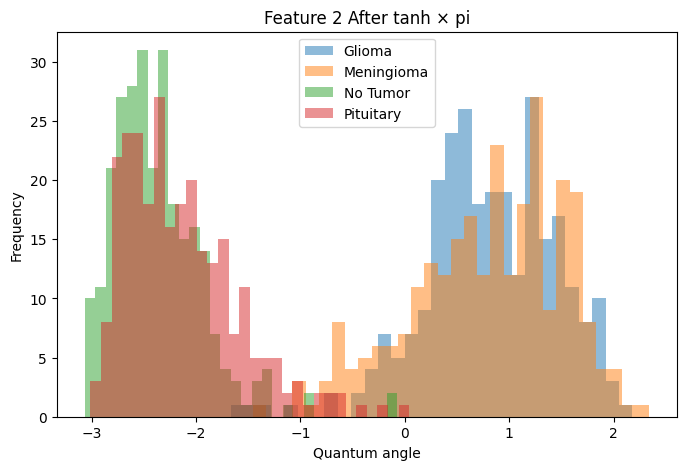

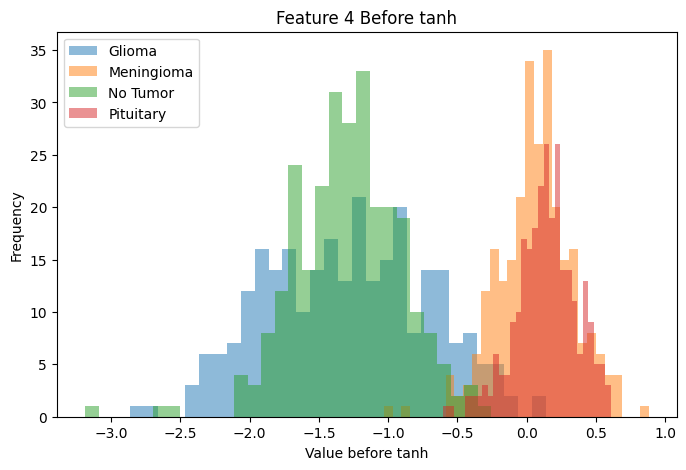

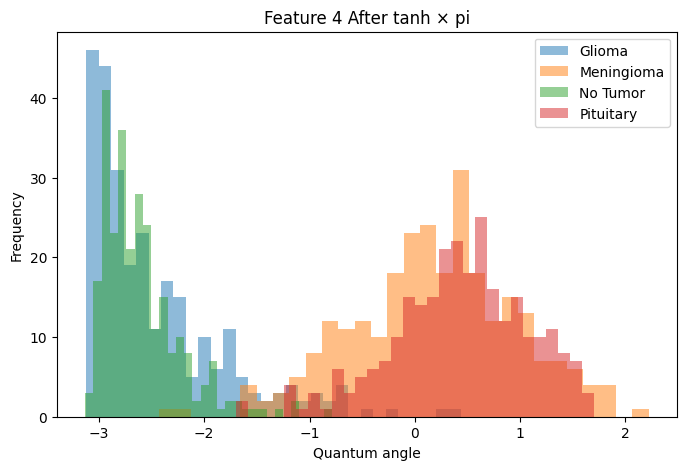

In [ ]:
import matplotlib.pyplot as plt

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

# Use validation labels
labels_np = val_labels.numpy()

raw_np = x_pre_tanh.numpy()
angles_np = angles.numpy()


for feature_idx in [1, 3]:   # Feature 2 and Feature 4

    # BEFORE tanh
    plt.figure(figsize=(8, 5))

    for class_idx, class_name in enumerate(class_names):

        values = raw_np[
            labels_np == class_idx,
            feature_idx
        ]

        plt.hist(
            values,
            bins=30,
            alpha=0.5,
            label=class_name
        )

    plt.xlabel("Value before tanh")
    plt.ylabel("Frequency")

    plt.title(
        f"Feature {feature_idx + 1} Before tanh"
    )

    plt.legend()
    plt.show()


    # AFTER tanh × pi
    plt.figure(figsize=(8, 5))

    for class_idx, class_name in enumerate(class_names):

        values = angles_np[
            labels_np == class_idx,
            feature_idx
        ]

        plt.hist(
            values,
            bins=30,
            alpha=0.5,
            label=class_name
        )

    plt.xlabel("Quantum angle")
    plt.ylabel("Frequency")

    plt.title(
        f"Feature {feature_idx + 1} After tanh × pi"
    )

    plt.legend()
    plt.show()

In [ ]:
# QUANTUM-SPACE CLASS SEPARATION
# Compare average RY-state similarity between different classes

labels_np = val_labels.cpu().numpy()

raw_angles = x_pre_tanh.cpu().numpy()
scaled_angles = angles.cpu().numpy()

class_names = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]


def mean_cross_class_fidelity(values, labels, class_a, class_b):

    a = values[labels == class_a]
    b = values[labels == class_b]

    # All pairwise angle differences
    differences = (
        a[:, None] - b[None, :]
    )

    # Fidelity between RY(theta)|0> states
    fidelity = np.cos(
        differences / 2
    ) ** 2

    return fidelity.mean()


print(
    "=== RY QUANTUM-STATE SIMILARITY ==="
)

print(
    "Higher value = classes encoded into more similar quantum states\n"
)


for feature_idx in range(N_QUBITS):

    print(
        f"FEATURE {feature_idx + 1}"
    )

    for class_a in range(4):

        for class_b in range(
            class_a + 1,
            4
        ):

            raw_fidelity = (
                mean_cross_class_fidelity(
                    raw_angles[:, feature_idx],
                    labels_np,
                    class_a,
                    class_b
                )
            )

            scaled_fidelity = (
                mean_cross_class_fidelity(
                    scaled_angles[:, feature_idx],
                    labels_np,
                    class_a,
                    class_b
                )
            )

            change = (
                scaled_fidelity
                - raw_fidelity
            )

            print(
                f"{class_names[class_a]} vs "
                f"{class_names[class_b]}:"
            )

            print(
                f"  Without tanh*pi: "
                f"{raw_fidelity:.4f}"
            )

            print(
                f"  With tanh*pi:    "
                f"{scaled_fidelity:.4f}"
            )

            print(
                f"  Change:          "
                f"{change:+.4f}"
            )

    print()

=== RY QUANTUM-STATE SIMILARITY ===
Higher value = classes encoded into more similar quantum states

FEATURE 1
Glioma vs Meningioma:
  Without tanh*pi: 0.9993
  With tanh*pi:    0.9931
  Change:          -0.0062
Glioma vs No Tumor:
  Without tanh*pi: 0.9994
  With tanh*pi:    0.9938
  Change:          -0.0056
Glioma vs Pituitary:
  Without tanh*pi: 0.9993
  With tanh*pi:    0.9933
  Change:          -0.0060
Meningioma vs No Tumor:
  Without tanh*pi: 0.9991
  With tanh*pi:    0.9909
  Change:          -0.0082
Meningioma vs Pituitary:
  Without tanh*pi: 0.9993
  With tanh*pi:    0.9928
  Change:          -0.0064
No Tumor vs Pituitary:
  Without tanh*pi: 0.9990
  With tanh*pi:    0.9905
  Change:          -0.0085

FEATURE 2
Glioma vs Meningioma:
  Without tanh*pi: 0.9718
  With tanh*pi:    0.8151
  Change:          -0.1567
Glioma vs No Tumor:
  Without tanh*pi: 0.6090
  With tanh*pi:    0.1264
  Change:          -0.4825
Glioma vs Pituitary:
  Without tanh*pi: 0.6772
  With tanh*pi:    0.1